# Deutsch-Jozsa and Grover with modern Qiskit


This notebook is a migration of the original CERN Aqua-based notebook to the current Qiskit API. Qiskit Aqua has been removed. Grover is provided by `qiskit_algorithms`, while Deutsch-Jozsa is implemented directly as a `QuantumCircuit` because there is no current `DeutschJozsa` algorithm class.


## Detusch-Jozsa

To use the Deutsch-Jozsa algorithm, we need to import some extra packages in addition to the ones we have been using.

In [1]:
%matplotlib inline

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.primitives import StatevectorSampler
from qiskit.circuit.library import PhaseOracleGate
from qiskit_algorithms import Grover, AmplificationProblem

sampler = StatevectorSampler()


The old Aqua `TruthTableOracle` class no longer exists. For the truth table `0101`, the function is 1 for `01` and `11`, so it depends only on the least-significant input bit. Below we create the equivalent bit-flip oracle circuit explicitly for the Deutsch-Jozsa algorithm.


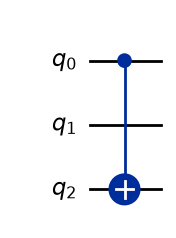

In [3]:
# Equivalent of TruthTableOracle("0101")
# Inputs: q[0], q[1]; target/output: q[2]
oracle = QuantumCircuit(3, name="Oracle")
oracle.cx(0, 2)

oracle.draw(output='mpl');


Aqua's `DeutschJozsa(oracle)` class has no current replacement. We therefore construct the standard Deutsch-Jozsa circuit around the oracle.


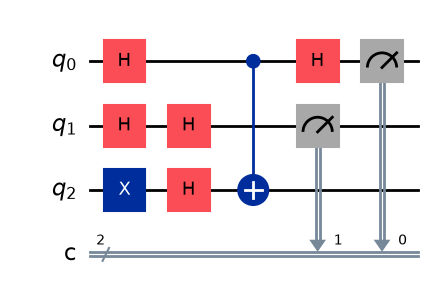

In [5]:
def deutsch_jozsa_circuit(oracle, num_inputs, measurement=True):
    qc = QuantumCircuit(num_inputs + 1, num_inputs if measurement else 0)
    output = num_inputs

    # Prepare the output qubit in |1>
    qc.x(output)

    # Put all qubits into superposition
    qc.h(range(num_inputs + 1))

    # Apply f(x)
    qc.compose(oracle, qubits=range(num_inputs + 1), inplace=True)

    # Interfere the input qubits
    qc.h(range(num_inputs))

    if measurement:
        qc.measure(range(num_inputs), range(num_inputs))

    return qc

dj = deutsch_jozsa_circuit(oracle, num_inputs=2, measurement=True)
dj.draw(output='mpl');


The old `QuantumInstance` execution model was removed. We execute the measured circuit with `StatevectorSampler`. For Deutsch-Jozsa, an all-zero measurement means constant; any nonzero input result means balanced.


In [6]:
job = sampler.run([dj], shots=1024)
result = job.result()
counts = result[0].data.c.get_counts()

print(counts)

most_likely = max(counts, key=counts.get)
verdict = "constant" if most_likely == "0" * 2 else "balanced"
print("The function is", verdict)


{'01': 1024}
The function is balanced


Let us check that it also works with a constant function.


In [7]:
# Truth table '00000000' is the constant-zero function on 3 input bits.
# Its oracle is therefore simply the identity on the inputs and output.
oracle2 = QuantumCircuit(4, name="Constant-0 Oracle")

dj2 = deutsch_jozsa_circuit(oracle2, num_inputs=3, measurement=True)
result2 = sampler.run([dj2], shots=1024).result()
counts2 = result2[0].data.c.get_counts()

most_likely2 = max(counts2, key=counts2.get)
verdict2 = "constant" if most_likely2 == "0" * 3 else "balanced"

print(counts2)
print("The function is", verdict2)


{'000': 1024}
The function is constant


# Grover

Modern Qiskit still provides Grover's algorithm through the separate `qiskit_algorithms` package. The oracle passed to Grover must be a phase-flip oracle, and the problem is wrapped in an `AmplificationProblem`.


In [8]:
# Old TruthTableOracle('0001'): the marked state is |11>.
oracle3 = PhaseOracleGate("x & y")
problem3 = AmplificationProblem(oracle3, is_good_state=["11"])

g = Grover(iterations=1, sampler=sampler)


Execution now uses `Grover.amplify(problem)` rather than Aqua's `run(QuantumInstance)`.


In [9]:
result = g.amplify(problem3)
print(result)
print("Top measurement:", result.top_measurement)
print("Oracle evaluation:", result.oracle_evaluation)


{   'assignment': '11',
    'circuit_results': [{'11': 1.0}],
    'iterations': [1],
    'max_probability': 1.0,
    'oracle_evaluation': True,
    'top_measurement': '11'}
Top measurement: 11
Oracle evaluation: True


Logical-expression oracles are still supported. The modern replacement is `PhaseOracleGate`, which accepts Python-like Boolean expressions.


In [10]:
expression = '(x | y) & (~y | z) & (~x | ~z | w) & (~x | y | z | ~w)'

oracle4 = PhaseOracleGate(expression)
problem4 = AmplificationProblem(oracle4)
g2 = Grover(iterations=3, sampler=sampler)

result = g2.amplify(problem4)
print(result)
print("Top measurement:", result.top_measurement)


{   'assignment': '0001',
    'circuit_results': [   {   '0000': 0.0244140625,
                               '0001': 0.1689453125,
                               '0010': 0.02734375,
                               '0011': 0.0322265625,
                               '0100': 0.0283203125,
                               '0101': 0.033203125,
                               '0110': 0.142578125,
                               '0111': 0.015625,
                               '1000': 0.0224609375,
                               '1001': 0.0244140625,
                               '1010': 0.0126953125,
                               '1011': 0.0244140625,
                               '1100': 0.0234375,
                               '1101': 0.126953125,
                               '1110': 0.130859375,
                               '1111': 0.162109375}],
    'iterations': [3],
    'max_probability': 0.1689453125,
    'oracle_evaluation': True,
    'top_measurement': '0001'}
Top measurement:

The old Aqua `incremental=True` option no longer exists. Modern `Grover` can instead try a sequence of iteration counts and optionally sample from those iteration counts. This is the closest maintained analogue for the unknown-solution-count case.


In [11]:
expression2 = '(x & y & z & w) | (~x & ~y & ~z & ~w)'
# expression2 = '(x & y) | (~x & ~y)'

oracle5 = PhaseOracleGate(expression2)
problem5 = AmplificationProblem(oracle5)

# Modern analogue of Aqua's incremental search mode.
g3 = Grover(
    iterations=[1, 2, 4],
    sample_from_iterations=True,
    sampler=sampler,
)

result = g3.amplify(problem5)
print(result)
print("Top measurement:", result.top_measurement)


{   'assignment': '0000',
    'circuit_results': [   {   '0000': 0.076171875,
                               '0001': 0.0615234375,
                               '0010': 0.0537109375,
                               '0011': 0.05859375,
                               '0100': 0.0625,
                               '0101': 0.0595703125,
                               '0110': 0.0576171875,
                               '0111': 0.0625,
                               '1000': 0.05859375,
                               '1001': 0.0712890625,
                               '1010': 0.0712890625,
                               '1011': 0.0634765625,
                               '1100': 0.0595703125,
                               '1101': 0.05859375,
                               '1110': 0.060546875,
                               '1111': 0.064453125}],
    'iterations': [1],
    'max_probability': 0.076171875,
    'oracle_evaluation': True,
    'top_measurement': '0000'}
Top measurement: 0000
